In [0]:
# IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

from sklearn.preprocessing import (StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer, QuantileTransformer)
from sklearn.metrics import silhouette_score

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

In [0]:
# 0) Load Spotify Tables (Spark → Pandas)

spotify_user_behavior = spark.table("workspace.spotify.spotify_user_behavior").toPandas()
spotify_user_demo     = spark.table("workspace.spotify.spotify_user_demo").toPandas()
print("Behavior shape:", spotify_user_behavior.shape)
print("Demo shape    :", spotify_user_demo.shape)

Behavior shape: (108000, 26)
Demo shape    : (108000, 6)


In [0]:
# 1) Manual Feature Selection 

CLUSTER_FEATURES_V1 = [
    "daily_listening_minutes",     # usage intensity
    "sessions_per_day",            # habit frequency
    "days_active_last_30",         # consistency
    "avg_session_minutes",         # depth per visit
    "skip_rate",                   # content friction
    "liked_songs_pct",             # positive engagement
    "ads_skipped_pct",             # ad tolerance / monetization friction
]
missing_cols = [c for c in (["user_id"] + CLUSTER_FEATURES_V1) if c not in spotify_user_behavior.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in spotify_user_behavior: {missing_cols}")

In [0]:
# 2) Build modeling base table 

base = spotify_user_behavior[["user_id"] + CLUSTER_FEATURES_V1].copy()
print("\nNull check (selected features):")
print(base[CLUSTER_FEATURES_V1].isnull().sum())
before_rows = len(base)
base = base.dropna(subset=CLUSTER_FEATURES_V1)
after_rows = len(base)
if before_rows != after_rows:
    print(f"\nDropped {before_rows - after_rows} rows due to nulls in selected features.")

# X_raw is the raw feature matrix in ORIGINAL units
X_raw = base[CLUSTER_FEATURES_V1].copy()
# Box-Cox requires strictly positive values
X_boxcox = X_raw.copy()
for col in X_boxcox.columns:
    min_val = X_boxcox[col].min()
    if min_val <= 0:
        X_boxcox[col] = (
            X_boxcox[col]
            + abs(min_val)
            + 1
        )


Null check (selected features):
daily_listening_minutes    0
sessions_per_day           0
days_active_last_30        0
avg_session_minutes        0
skip_rate                  0
liked_songs_pct            0
ads_skipped_pct            0
dtype: int64


In [0]:
# 3) USER CONTROLS

K = 4
RANDOM_STATE = 42
experiments = [
    # KMEANS
    ("kmeans", "unscaled"),
    ("kmeans", "standard"),
    ("kmeans", "robust"),
    ("kmeans", "minmax"),
    ("kmeans", "power_yeojohnson"),
    ("kmeans", "power_boxcox"),
    ("kmeans", "quantile_uniform"),

    # GMM 

    ("gmm_full", "standard"),
    ("gmm_tied", "standard"),
    ("gmm_diag", "standard"),
    ("gmm_spherical", "standard"),

    ("gmm_full", "robust"),
    ("gmm_tied", "robust"),
    ("gmm_diag", "robust"),
    ("gmm_spherical", "robust"),

    ("gmm_full", "minmax"),
    ("gmm_tied", "minmax"),
    ("gmm_diag", "minmax"),
    ("gmm_spherical", "minmax"),

    ("gmm_full", "power_yeojohnson"),
    ("gmm_tied", "power_yeojohnson"),
    ("gmm_diag", "power_yeojohnson"),
    ("gmm_spherical", "power_yeojohnson"),
]

In [0]:
# 4) Transformer Library

def transform_X(method_name: str, X: pd.DataFrame):
    note = ""

    # Unscaled
    if method_name == "unscaled":
        return X.copy(), note

    # StandardScaler
    if method_name == "standard":
        scaler = StandardScaler()
        arr = scaler.fit_transform(X)
        return pd.DataFrame(arr, columns=X.columns, index=X.index), note

    # MinMaxScaler
    if method_name == "minmax":
        scaler = MinMaxScaler()
        arr = scaler.fit_transform(X)
        return pd.DataFrame(arr, columns=X.columns, index=X.index), note

    # RobustScaler
    if method_name == "robust":
        scaler = RobustScaler()
        arr = scaler.fit_transform(X)
        return pd.DataFrame(arr, columns=X.columns, index=X.index), note

    # PowerTransformer(YJ)
    if method_name == "power_yeojohnson":
        pt = PowerTransformer(method="yeo-johnson", standardize=True)
        arr = pt.fit_transform(X)
        return pd.DataFrame(arr, columns=X.columns, index=X.index), note

    # PowerTransformer(Bc)
    if method_name == "power_boxcox":
        pt = PowerTransformer(method="box-cox",standardize=True)
        arr = pt.fit_transform(X_boxcox)
        return pd.DataFrame(arr,columns=X.columns,index=X.index), note

    # Quantile Transformer (
    if method_name == "quantile_uniform":
        qt = QuantileTransformer(output_distribution="uniform",random_state=42)
        arr = qt.fit_transform(X)
        return pd.DataFrame(arr,columns=X.columns,index=X.index), note
    raise ValueError(f"Unknown method_name: {method_name}")

In [0]:
# 5) Algorithm Library

def fit_predict_labels(algorithm_key: str, X_fit: pd.DataFrame, k: int, random_state: int):
    extra = {}

    # KMeans
    if algorithm_key == "kmeans":
        km = KMeans(
            n_clusters=k,
            random_state=random_state,
            n_init=20,
            max_iter=300
        )
        labels = km.fit_predict(X_fit)
        extra["inertia"] = float(km.inertia_)
        return labels, "K-Means", extra

    # GMM - Full covariance
    if algorithm_key == "gmm_full":
        gmm = GaussianMixture(
            n_components=k,
            covariance_type="full",
            random_state=random_state,
            n_init=5,
            max_iter=200
        )
        labels = gmm.fit_predict(X_fit)
        extra["log_likelihood"] = float(gmm.score(X_fit) * len(X_fit))
        extra["aic"] = float(gmm.aic(X_fit))
        extra["bic"] = float(gmm.bic(X_fit))
        return labels, "GMM - Full", extra

    # GMM - Tied covariance
    if algorithm_key == "gmm_tied":
        gmm = GaussianMixture(
            n_components=k,
            covariance_type="tied",
            random_state=random_state,
            n_init=5,
            max_iter=200
        )
        labels = gmm.fit_predict(X_fit)
        extra["log_likelihood"] = float(gmm.score(X_fit) * len(X_fit))
        extra["aic"] = float(gmm.aic(X_fit))
        extra["bic"] = float(gmm.bic(X_fit))
        return labels, "GMM - Tied", extra

    # GMM - Diagonal covariance
    if algorithm_key == "gmm_diag":
        gmm = GaussianMixture(
            n_components=k,
            covariance_type="diag",
            random_state=random_state,
            n_init=5,
            max_iter=200
        )
        labels = gmm.fit_predict(X_fit)
        extra["log_likelihood"] = float(gmm.score(X_fit) * len(X_fit))
        extra["aic"] = float(gmm.aic(X_fit))
        extra["bic"] = float(gmm.bic(X_fit))
        return labels, "GMM - Diag", extra

    # GMM - Spherical covariance
    if algorithm_key == "gmm_spherical":
        gmm = GaussianMixture(
            n_components=k,
            covariance_type="spherical",
            random_state=random_state,
            n_init=5,
            max_iter=200
        )
        labels = gmm.fit_predict(X_fit)
        extra["log_likelihood"] = float(gmm.score(X_fit) * len(X_fit))
        extra["aic"] = float(gmm.aic(X_fit))
        extra["bic"] = float(gmm.bic(X_fit))
        return labels, "GMM - Spherical", extra

    raise ValueError(f"Unknown algorithm_key: {algorithm_key}")

In [0]:
# 6) Run Experiment Grid 

results = []
for algo_key, method_key in experiments:

        # Step A: Transform raw features into fit space
        X_fit, note = transform_X(method_key, X_raw)

        # If transform is invalid (e.g., Box-Cox constraints), store "skipped" row
        if X_fit is None:
            results.append({
                "Algorithm": "(SKIPPED)",
                "Method": method_key,
                "Silhouette": np.nan,
                "Cluster_0_Count": np.nan,
                "Cluster_1_Count": np.nan,
                "Cluster_2_Count": np.nan,
                "Cluster_3_Count": np.nan,
                "Inertia": np.nan,
                "LogLikelihood": np.nan,
                "AIC": np.nan,
                "BIC": np.nan,
                "Note": note,
                "AlgoKey": algo_key  # keep internal key for traceability
            })
            continue

        # Step B: Fit algorithm and get hard labels
        labels, algo_label, extra = fit_predict_labels(algo_key, X_fit, K, RANDOM_STATE)

        # Step C: Silhouette computed in fit space (correct)
        sil = np.nan
        if len(np.unique(labels)) > 1 and len(X_fit) > K:
            sil = float(silhouette_score(X_fit, labels))

        # Step D: Cluster counts
        counts = pd.Series(labels).value_counts().sort_index()
        c0 = int(counts.get(0, 0))
        c1 = int(counts.get(1, 0))
        c2 = int(counts.get(2, 0))
        c3 = int(counts.get(3, 0))

        # Step E: Build results row
        row = {
            "Algorithm": algo_label,
            "Method": method_key,
            "Silhouette": sil,
            "Cluster_0_Count": c0,
            "Cluster_1_Count": c1,
            "Cluster_2_Count": c2,
            "Cluster_3_Count": c3,
            "Inertia": extra.get("inertia", np.nan),
            "LogLikelihood": extra.get("log_likelihood", np.nan),
            "AIC": extra.get("aic", np.nan),
            "BIC": extra.get("bic", np.nan),
            "Note": note,
            "AlgoKey": algo_key  # internal key so we can re-run later reliably
        }
        results.append(row)

results_df = pd.DataFrame(results)

# Add iteration numbers like your tracking sheet
results_df.insert(0, "Iteration", range(1, len(results_df) + 1))

# Round columns for readability
results_df["Silhouette"] = results_df["Silhouette"].round(3)
results_df["Inertia"] = results_df["Inertia"].round(2)
results_df["LogLikelihood"] = results_df["LogLikelihood"].round(2)
results_df["AIC"] = results_df["AIC"].round(2)
results_df["BIC"] = results_df["BIC"].round(2)

print("\n===== EXPERIMENT SUMMARY (results_df) =====")
display(results_df)


===== EXPERIMENT SUMMARY (results_df) =====


Iteration,Algorithm,Method,Silhouette,Cluster_0_Count,Cluster_1_Count,Cluster_2_Count,Cluster_3_Count,Inertia,LogLikelihood,AIC,BIC,Note,AlgoKey
1,K-Means,unscaled,0.515,64364,11069,1903,30664,5.370342773E7,null,null,null,,kmeans
2,K-Means,standard,0.152,41989,42596,17315,6100,488693.28,null,null,null,,kmeans
3,K-Means,robust,0.16,49918,5012,36620,16450,296999.51,null,null,null,,kmeans
4,K-Means,minmax,0.18,29103,21670,29439,27788,10090.21,null,null,null,,kmeans
5,K-Means,power_yeojohnson,0.166,17925,37460,26899,25716,471012.28,null,null,null,,kmeans
6,K-Means,power_boxcox,0.165,26855,25730,37441,17974,472074.68,null,null,null,,kmeans
7,K-Means,quantile_uniform,0.191,24760,24130,38783,20327,38558.95,null,null,null,,kmeans
8,GMM - Full,standard,0.141,61345,12889,7514,26252,null,366820.29,-733354.57,-731983.22,,gmm_full
9,GMM - Tied,standard,0.158,6710,19685,78345,3260,null,-890822.4,1781762.8,1782328.61,,gmm_tied
10,GMM - Diag,standard,0.124,56353,30861,8127,12659,null,-271016.25,542150.51,542716.31,,gmm_diag


In [0]:
# 7) Selecting BEST iteration number

BEST_ITERATION_NUMBER = 4 
best_row = results_df.loc[results_df["Iteration"] == BEST_ITERATION_NUMBER]
if best_row.empty:
    raise ValueError(f"Iteration {BEST_ITERATION_NUMBER} not found in results_df.")

best_algo_key = best_row["AlgoKey"].iloc[0]
best_algo_label = best_row["Algorithm"].iloc[0]
best_method_key = best_row["Method"].iloc[0]
best_note = best_row["Note"].iloc[0]

print("\n" + "=" * 70)
print("BEST ITERATION SELECTED (Option A)")
print("=" * 70)
print("Iteration :", BEST_ITERATION_NUMBER)
print("Algorithm :", best_algo_label, f"(internal key = {best_algo_key})")
print("Method    :", best_method_key)
print("Note      :", best_note)

# Recreate the fit-space features for the selected best method
X_best, note_best = transform_X(best_method_key, X_raw)
if X_best is None:
    raise ValueError(f"Best iteration uses a skipped method '{best_method_key}'. Reason: {note_best}")

# Fit + predict best labels
labels_best, algo_label_check, extra_best = fit_predict_labels(best_algo_key, X_best, K, RANDOM_STATE)

# Optional: recompute silhouette for selected best choice (fit space)
sil_best = np.nan
if len(np.unique(labels_best)) > 1 and len(X_best) > K:
    sil_best = float(silhouette_score(X_best, labels_best))

print("\nRecomputed best silhouette:", None if np.isnan(sil_best) else round(sil_best, 3))

# Append labels back to the modeling input table
output_with_best_clusters = base.copy()
output_with_best_clusters["best_cluster"] = labels_best

# Add metadata columns (helps trace what was applied)
output_with_best_clusters["best_iteration"] = BEST_ITERATION_NUMBER
output_with_best_clusters["best_algorithm"] = best_algo_label
output_with_best_clusters["best_method"] = best_method_key

print("\n===== OUTPUT WITH BEST CLUSTERS APPENDED (preview) =====")
display(output_with_best_clusters.head(20))



BEST ITERATION SELECTED (Option A)
Iteration : 4
Algorithm : K-Means (internal key = kmeans)
Method    : minmax
Note      : 

Recomputed best silhouette: 0.18

===== OUTPUT WITH BEST CLUSTERS APPENDED (preview) =====


user_id,daily_listening_minutes,sessions_per_day,days_active_last_30,avg_session_minutes,skip_rate,liked_songs_pct,ads_skipped_pct,best_cluster,best_iteration,best_algorithm,best_method
1,27.8600331451566240,1,23.6207488045328230,27.8600331451566240,0.2652434107382756,0.36692289422245106000,0.259908069477194640,0,4,K-Means,minmax
2,53.2801594511560000,1,26.0207578957064800,53.2801594511560000,0.11895906967561629,0.18486652918685878000,0.474921265102942000,0,4,K-Means,minmax
3,28.8699017515535380,1,26.6913056253024500,28.8699017515535380,0.24495348616154713,0.37373733562904693000,0.579176556554077500,0,4,K-Means,minmax
4,35.6438224704689800,3,23.0407140984317420,11.8812741568229950,0.5089164221034259,0.42716084080857790000,0.416055703228579770,1,4,K-Means,minmax
5,14.5473124274416070,1,11.0992860211953170,14.5473124274416070,0.10554031013923311,0.25317912948661997000,0.603254728153022100,3,4,K-Means,minmax
6,49.0482613603114300,1,22.8677899039699530,49.0482613603114300,0.5228284880895235,0.41789807559922626000,0.501709079331418800,1,4,K-Means,minmax
7,39.0675542043531860,1,24.1310988367131200,39.0675542043531860,0.19844738038538784,0.36640395438542317000,0.797580554810954900,2,4,K-Means,minmax
8,68.7550313000483600,1,22.5645636143413060,68.7550313000483600,0.30312822049960575,0.19988937038559823000,0.351844191152380500,0,4,K-Means,minmax
9,26.5281640283802670,1,14.8994779230759220,26.5281640283802670,0.15995640202723563,0.45202474548709604000,0.238483527697036730,3,4,K-Means,minmax
10,87.1022142259386700,3,16.4727818616599430,29.0340714086462230,0.2155832200876116,0.47697352960945594000,0.667138621671540900,2,4,K-Means,minmax


In [0]:
# 8) Join clusters with demographics

persona_df = output_with_best_clusters.merge(
    spotify_user_demo,
    on="user_id",
    how="left"
)

print("Final joined shape:", persona_df.shape)
display(persona_df.head())

Final joined shape: (108000, 17)


user_id,daily_listening_minutes,sessions_per_day,days_active_last_30,avg_session_minutes,skip_rate,liked_songs_pct,ads_skipped_pct,best_cluster,best_iteration,best_algorithm,best_method,age,country,city_tier,device_type,subscription_tenure_months
1,27.8600331451566240,1,23.6207488045328230,27.8600331451566240,0.2652434107382756,0.36692289422245106000,0.259908069477194640,0,4,K-Means,minmax,49.881607316152895,UK,2,Desktop,11.3526983494597180
2,53.2801594511560000,1,26.0207578957064800,53.2801594511560000,0.11895906967561629,0.18486652918685878000,0.474921265102942000,0,4,K-Means,minmax,38.059871002344835,US,3,Mobile,21.7985155333668850
3,28.8699017515535380,1,26.6913056253024500,28.8699017515535380,0.24495348616154713,0.37373733562904693000,0.579176556554077500,0,4,K-Means,minmax,32.682443546344990,IN,1,Mobile,13.4000720878786750
4,35.6438224704689800,3,23.0407140984317420,11.8812741568229950,0.5089164221034259,0.42716084080857790000,0.416055703228579770,1,4,K-Means,minmax,24.275915118611570,DE,1,Desktop,24.3964678247501500
5,14.5473124274416070,1,11.0992860211953170,14.5473124274416070,0.10554031013923311,0.25317912948661997000,0.603254728153022100,3,4,K-Means,minmax,44.354491038023205,IN,2,Mobile,6.9213671864594880


In [0]:
# 9) Cluster size & share distribution

cluster_sizes = persona_df["best_cluster"].value_counts().sort_index()
cluster_share = (cluster_sizes / cluster_sizes.sum()).round(3)
cluster_dist = pd.DataFrame({
    "cluster_size": cluster_sizes,
    "cluster_share": cluster_share
})
print("\nCluster Size & Share:")
display(cluster_dist)


Cluster Size & Share:


cluster_size,cluster_share
29103,0.269
21670,0.201
29439,0.273
27788,0.257


In [0]:
# 10) Numeric Profiling

numeric_cols = ["age", "subscription_tenure_months"]
numeric_profile = (
    persona_df
    .groupby("best_cluster")[numeric_cols]
    .mean()
    .round(2)
)

print("\nNumeric Means by Cluster:")
display(numeric_profile)
# Index vs overall population
overall_means = persona_df[numeric_cols].mean()
numeric_index = (numeric_profile / overall_means).round(3)
print("\nNumeric Index vs Overall (cluster_mean / overall_mean):")
display(numeric_index)


Numeric Means by Cluster:


age,subscription_tenure_months
32.433421405383164,18.121158410801968
32.38530612107328,17.91579995696
32.34803472130031,17.999931952051746
32.39281702482184,18.090858483843288



Numeric Index vs Overall (cluster_mean / overall_mean):


age,subscription_tenure_months
1.001339195010017,1.0045481816954829
0.9998536989392712,0.993164115802666
0.9987029935302092,0.9978279811459239
1.0000855882061905,1.0028685022929948


In [0]:
# 11) Categorical Profiling — Proportional Distributions

country_dist = pd.crosstab(
    persona_df["best_cluster"],
    persona_df["country"],
    normalize="index"
).round(3)
print("\nCountry Distribution by Cluster:")
display(country_dist)
city_tier_dist = pd.crosstab(
    persona_df["best_cluster"],
    persona_df["city_tier"],
    normalize="index"
).round(3)

print("\nCity Tier Distribution by Cluster:")
display(city_tier_dist)
device_dist = pd.crosstab(
    persona_df["best_cluster"],
    persona_df["device_type"],
    normalize="index"
).round(3)
print("\nDevice Type Distribution by Cluster:")
display(device_dist)


Country Distribution by Cluster:


BR,DE,IN,UK,US
0.103,0.149,0.248,0.147,0.353
0.097,0.153,0.252,0.152,0.346
0.101,0.146,0.25,0.153,0.35
0.097,0.15,0.254,0.147,0.351



City Tier Distribution by Cluster:


1,2,3
0.398,0.353,0.249
0.404,0.345,0.251
0.398,0.352,0.25
0.404,0.35,0.247



Device Type Distribution by Cluster:


Desktop,Mobile,Tablet
0.255,0.695,0.05
0.253,0.697,0.05
0.249,0.699,0.051
0.25,0.701,0.049


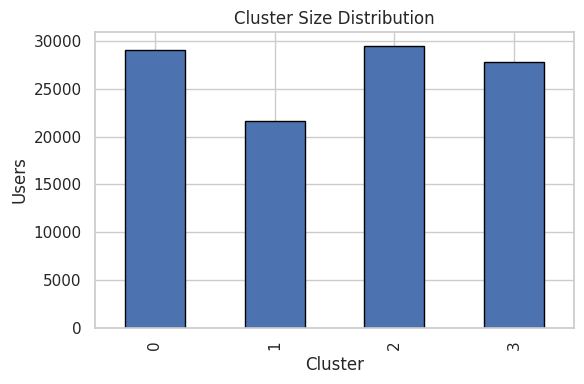

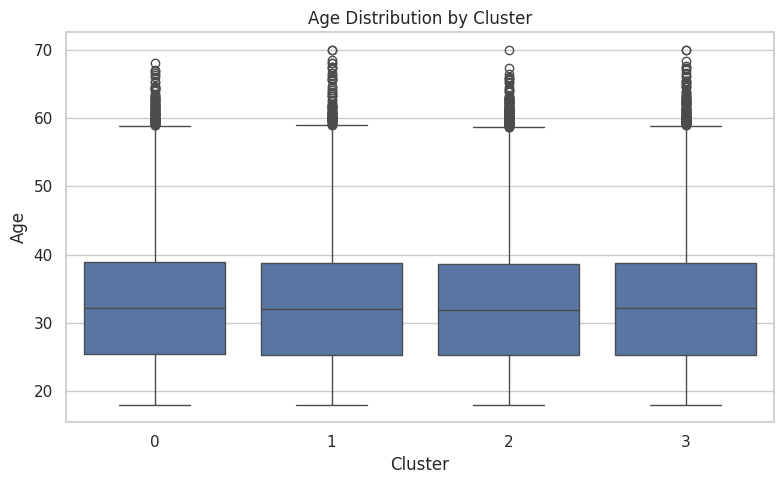

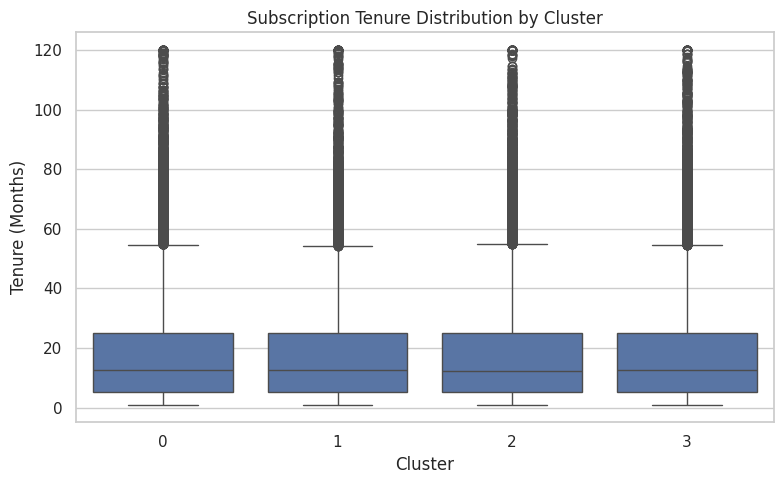

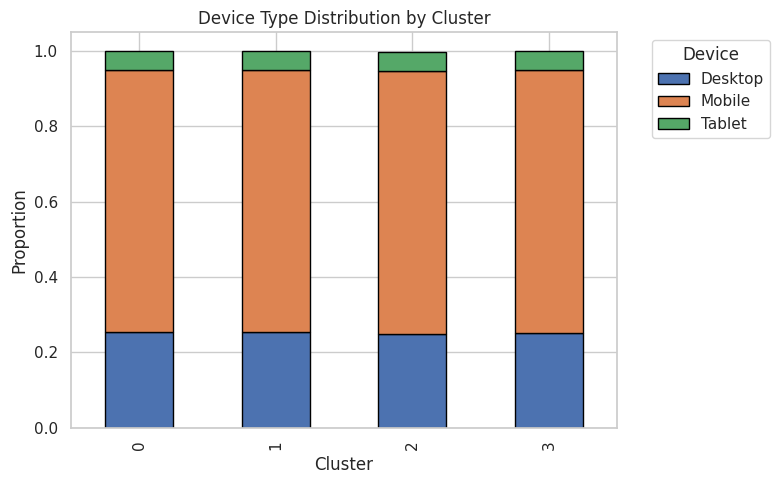

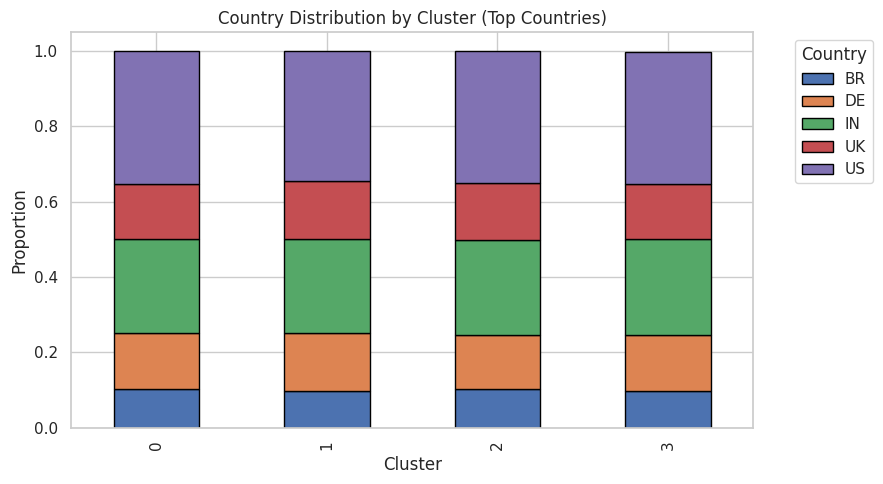

In [0]:
# 12) Visualizations

# Cluster Size Distribution
plt.figure(figsize=(6,4))
persona_df["best_cluster"].value_counts().sort_index().plot(
    kind="bar", edgecolor="black"
)
plt.title("Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Users")
plt.tight_layout()
plt.show()

# ---- Age Distribution by Cluster
plt.figure(figsize=(8,5))
sns.boxplot(
    data=persona_df,
    x="best_cluster",
    y="age"
)
plt.title("Age Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

# ---- Tenure Distribution by Cluster
plt.figure(figsize=(8,5))
sns.boxplot(
    data=persona_df,
    x="best_cluster",
    y="subscription_tenure_months"
)
plt.title("Subscription Tenure Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Tenure (Months)")
plt.tight_layout()
plt.show()

# ---- Device Distribution (Stacked Bar)
device_dist.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    edgecolor="black"
)
plt.title("Device Type Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.legend(title="Device", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()

# ---- Country Distribution (Top 6 countries only for readability)
top_countries = persona_df["country"].value_counts().head(6).index

country_dist_top = pd.crosstab(
    persona_df["best_cluster"],
    persona_df["country"].where(persona_df["country"].isin(top_countries), "Other"),
    normalize="index"
).round(3)

country_dist_top.plot(
    kind="bar",
    stacked=True,
    figsize=(9,5),
    edgecolor="black"
)

plt.title("Country Distribution by Cluster (Top Countries)")
plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.legend(title="Country", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()

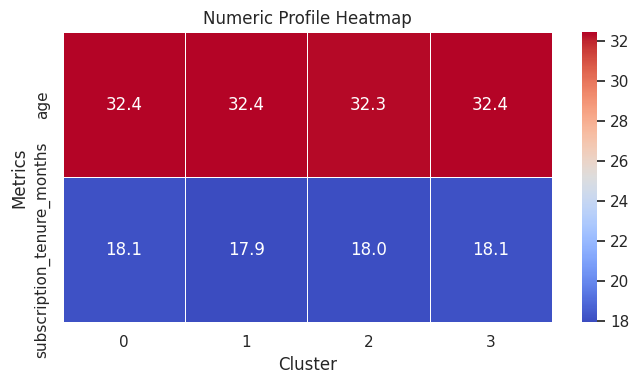

In [0]:
# 13) Heatmap — Numeric Persona Profile
numeric_profile = numeric_profile.astype(float)
plt.figure(figsize=(7,4))
sns.heatmap(
    numeric_profile.T,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Numeric Profile Heatmap")
plt.xlabel("Cluster")
plt.ylabel("Metrics")
plt.tight_layout()
plt.show()